In [1]:
import os.path as osp
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.utils as vutils

from src.datasets import DatasetBuilder

from src.utils import seed_everything, get_config, load_model_weights
from src.cf_methods.c3lt import models 


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
I0000 00:00:1775733963.890167    2713 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
seed_everything()

plt.style.use('seaborn-v0_8-darkgrid')
params = {"text.color" : "black"}
plt.rcParams.update(params)

## Load data

In [3]:
repo_path = r'/teamspace/studios/this_studio/CF-Robustness-Benchmark'  
config_path = osp.join(repo_path, r'configs/train_classifier_fmnist.yaml')

config = get_config(config_path)
config.data.classes = [0, 2, 4, 6]
# config.data.classes = [i for i in range(10)]
config.data.num_classes = 4
config.data_dir = osp.join(repo_path, config.data_dir)

BATCH_SIZE = 256 #config.batch_size
img_size = config.data.img_size
DEVICE = 'cuda'  if torch.cuda.is_available()  else 'cpu'

In [4]:
ds_builder = DatasetBuilder(config)
ds_builder.setup()
train_loader, val_loader, test_loader = ds_builder.get_dataloaders()

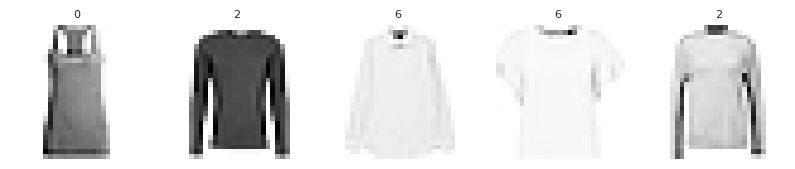

In [5]:
plt.style.use('seaborn-v0_8-darkgrid')

n_samples = 5
class_names = ds_builder.class_encodings
fig, axs = plt.subplots(1, n_samples, figsize=(10, 6))

batch = next(iter(train_loader))
images = batch[0][:n_samples]
labels = batch[1][:n_samples]

for i in range(n_samples):
    axs[i].imshow(images[i, ...].permute(1, 2, 0))
    axs[i].set_title(class_names[labels[i].item()], fontdict={'fontsize': 8})
    axs[i].axis("off")

In [6]:
z = 100
ngf = 64 # Size of feature maps in generator
ndf = 64 # Size of feature maps in discriminator
nc = 1 # Number of channels
beta1 = 0.5 # Beta1 hyperparameter for Adam optimizers
lr = 0.0002 # Learning rate for optimizers
device = 'cuda' if torch.cuda.is_available() else 'cpu' 

## Build DCGAN object  

In [19]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [20]:
gen = models.Generator(latent_dim=z, ngf=ngf, nc=nc).to(device)
discr = models.Discriminator(ndf=ndf, nc=1).to(device)

gen.apply(weights_init);
discr.apply(weights_init);

## Train DCGAN

In [8]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(BATCH_SIZE, z, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.

# Setup Adam optimizers for both G and D
optimizerG = torch.optim.Adam(gen.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerD = torch.optim.Adam(discr.parameters(), lr=lr, betas=(beta1, 0.999))

In [10]:
# Training Loop

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0
num_epochs = 15

print("Starting Training Loop...")
# For each epoch
for epoch in range(num_epochs):
    # For each batch in the dataloader
    for i, data in enumerate(train_loader, 0):

        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        discr.zero_grad()
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = discr(real_cpu).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, z, 1, 1, device=device)
        # Generate fake image batch with G
        fake = gen(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = discr(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and the real batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        gen.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = discr(fake).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(train_loader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(test_loader)-1)):
            with torch.no_grad():
                fake = gen(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

Starting Training Loop...
[0/15][0/158]	Loss_D: 1.6868	Loss_G: 1.4694	D(x): 0.4016	D(G(z)): 0.4964 / 0.2504
[0/15][50/158]	Loss_D: 0.1050	Loss_G: 5.3708	D(x): 0.9258	D(G(z)): 0.0258 / 0.0067
[0/15][100/158]	Loss_D: 0.1623	Loss_G: 3.6356	D(x): 0.9126	D(G(z)): 0.0647 / 0.0336
[0/15][150/158]	Loss_D: 0.2930	Loss_G: 3.9627	D(x): 0.9131	D(G(z)): 0.1707 / 0.0229
[1/15][0/158]	Loss_D: 0.9371	Loss_G: 3.1895	D(x): 0.5016	D(G(z)): 0.0300 / 0.0665
[1/15][50/158]	Loss_D: 0.4093	Loss_G: 3.9177	D(x): 0.9190	D(G(z)): 0.2533 / 0.0272
[1/15][100/158]	Loss_D: 0.4216	Loss_G: 3.2817	D(x): 0.8633	D(G(z)): 0.2068 / 0.0598
[1/15][150/158]	Loss_D: 0.4572	Loss_G: 2.3172	D(x): 0.7675	D(G(z)): 0.1295 / 0.1466
[2/15][0/158]	Loss_D: 0.5444	Loss_G: 3.1786	D(x): 0.9243	D(G(z)): 0.3287 / 0.0566
[2/15][50/158]	Loss_D: 0.5018	Loss_G: 3.0510	D(x): 0.8332	D(G(z)): 0.2346 / 0.0689
[2/15][100/158]	Loss_D: 0.9272	Loss_G: 4.2291	D(x): 0.9034	D(G(z)): 0.5180 / 0.0200
[2/15][150/158]	Loss_D: 0.5419	Loss_G: 1.8961	D(x): 0.7969	

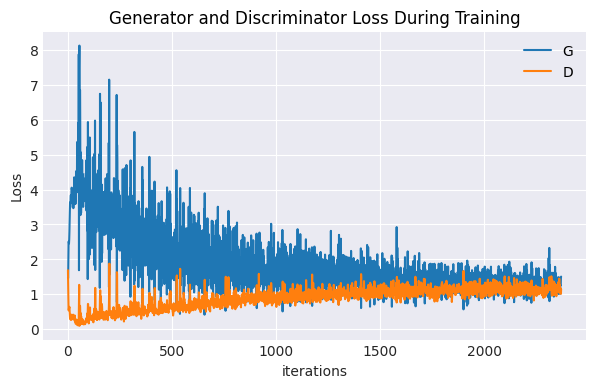

In [11]:
plt.figure(figsize=(7,4))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

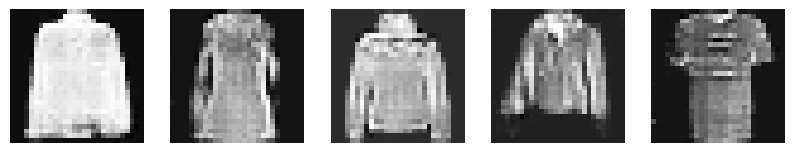

In [89]:
n_samples = 5
fig, axs = plt.subplots(1, n_samples, figsize=(10, 4))

noise_vector = torch.randn(BATCH_SIZE, z, 1, 1, device=device)
gen_images = gen(noise_vector).detach().cpu()

for j in range(n_samples):
    axs[j].imshow(gen_images[j].squeeze(0), cmap='gray')
    axs[j].axis("off")


In [13]:
save_dir = osp.join(repo_path,  r'src/cf_methods/c3lt/weights')

torch.save(gen.state_dict(), osp.join(save_dir, r'generator_fmnist_1_8.pth'))
torch.save(discr.state_dict(), osp.join(save_dir, r'discriminator_fmnist_1_8.pth'))

Compute FID

In [18]:
from torchmetrics.image.fid import FrechetInceptionDistance

In [57]:
repo_path = r'/data/leuven/365/vsc36567/CF-Robustness-Benchmark'  # "D:\PycharmProjects\CF-Robustness-Benchmark" 
config_path = osp.join(repo_path, r'configs/train_classifier_fmnist.yaml')

config = get_config(config_path)
config.data_dir = osp.join(repo_path, config.data_dir)
config.data.classes = [0, 4]
config.data.num_classes = len(config.data.classes)

ds_builder = DatasetBuilder(config)
ds_builder.setup()
train_loader, val_loader, test_loader = ds_builder.get_dataloaders()

In [83]:
gen_weights = '/data/leuven/365/vsc36567/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/fmnist/generator_fmnist_0_4.pth'
disc_weights = '/data/leuven/365/vsc36567/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/fmnist/discriminator_fmnist_0_4.pth'
load_model_weights(gen, weights_path=gen_weights)
load_model_weights(discr, weights_path=disc_weights)

In [77]:
binary_fid = FrechetInceptionDistance(feature=64)
# generate two slightly overlapping image intensity distributions
real_imgs, _ = next(iter(test_loader))
fake_imgs = gen(fixed_noise).detach().cpu()

In [78]:
binary_fid.update(torch.tile(real_imgs.to(dtype=torch.uint8), dims=(1, 3, 1, 1)), real=True)
binary_fid.update(torch.tile(fake_imgs.to(dtype=torch.uint8), dims=(1, 3, 1, 1)), real=False)
print('FID in binary setting on MNIST: {:.7f}'.format(binary_fid.compute()))

FID in binary setting on MNIST: 0.0000383


In [79]:
config.data.classes = [0, 2, 4, 6] # list(range(10))
config.data.num_classes = len(config.data.classes)

ds_builder = DatasetBuilder(config)
ds_builder.setup()
train_loader, val_loader, test_loader = ds_builder.get_dataloaders()

In [80]:
_, labels = next(iter(train_loader))
labels

tensor([0, 2, 2, 1, 3, 0, 3, 3, 0, 0, 1, 1, 1, 2, 2, 1, 1, 0, 0, 0, 0, 2, 1, 3,
        1, 2, 1, 2, 0, 2, 2, 2, 2, 3, 3, 2, 3, 1, 3, 0, 0, 1, 3, 0, 3, 1, 2, 1,
        1, 0, 3, 2, 3, 2, 2, 3, 0, 2, 3, 1, 3, 3, 1, 2])

In [81]:
gen_weights = '/data/leuven/365/vsc36567/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/fmnist/generator_fmnist.pth'
disc_weights = '/data/leuven/365/vsc36567/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/fmnist/discriminator_fmnist.pth'
load_model_weights(gen, weights_path=gen_weights)
load_model_weights(discr, weights_path=disc_weights)

In [82]:
multi_fid = FrechetInceptionDistance(feature=64)
# generate two slightly overlapping image intensity distributions
real_imgs, _ = next(iter(test_loader))
fake_imgs = gen(fixed_noise).detach().cpu()

multi_fid.update(torch.tile(real_imgs.to(dtype=torch.uint8), dims=(1, 3, 1, 1)), real=True)
multi_fid.update(torch.tile(fake_imgs.to(dtype=torch.uint8), dims=(1, 3, 1, 1)), real=False)
print('FID in multicclass setting on MNIST: {:.7f}'.format(multi_fid.compute()))

FID in multicclass setting on MNIST: 0.0000383


## Train AE

In [7]:
from torchvision.models import vgg16
import os

In [8]:
gen = models.Generator(latent_dim=z, ngf=ngf, nc=nc).to(DEVICE)
discr = models.Discriminator(ndf=ndf, nc=nc).to(DEVICE)

gen_weights = '/teamspace/studios/this_studio/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/fmnist/generator_fmnist.pth'
disc_weights = '/teamspace/studios/this_studio/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/fmnist/discriminator_fmnist.pth'

load_model_weights(gen, weights_path=gen_weights)
load_model_weights(discr, weights_path=disc_weights)

In [9]:
encoder = models.Encoder(latent_dim=z, nc=nc, ndf=ndf, ngpu=1).to(DEVICE)

In [10]:
# ═══════════════════════════════════════════════════════════════
#  LOSSES
# ═══════════════════════════════════════════════════════════════
class PerceptualLoss(nn.Module):
    """VGG16-based perceptual loss."""
    def __init__(self):
        super().__init__()
        vgg = vgg16(pretrained=True).features[:16].eval()
        for p in vgg.parameters():
            p.requires_grad = False
        self.vgg = vgg
 
    def forward(self, pred, target):
        mean = torch.tensor([0.485, 0.456, 0.406], device=pred.device).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=pred.device).view(1, 3, 1, 1)
        pred_norm = ((pred + 1) / 2 - mean) / std
        target_norm = ((target + 1) / 2 - mean) / std
        return nn.functional.mse_loss(self.vgg(pred_norm), self.vgg(target_norm))

In [11]:
LR = 1e-2
N_EPOCHS = 30
LAMBDA_PERCEPTUAL = 0.1
LAMBDA_ADV = 0.01

# ═══════════════════════════════════════════════════════════════
#  TRAINING FUNCTION
# ═══════════════════════════════════════════════════════════════
def train_encoder(encoder, generator, discriminator, train_loader,
                  n_epochs=N_EPOCHS, lr=LR,
                  lambda_perceptual=LAMBDA_PERCEPTUAL,
                  lambda_adv=LAMBDA_ADV,
                  device=DEVICE, save_dir=None):
    """
    Train encoder against frozen generator and discriminator.
    
    Args:
        encoder: Encoder network (trainable)
        generator: Pretrained DCGAN generator (frozen)
        discriminator: Pretrained DCGAN discriminator (frozen)
        train_loader: DataLoader with images in [-1, 1] range
        n_epochs: Number of training epochs
        lr: Learning rate
        lambda_perceptual: Weight for VGG perceptual loss
        lambda_adv: Weight for adversarial loss from discriminator
        device: cuda/cpu
        save_dir: Directory to save encoder weights
    """
    # Freeze generator and discriminator
    generator.eval()
    discriminator.eval()
    for p in generator.parameters():
        p.requires_grad = False
    for p in discriminator.parameters():
        p.requires_grad = False
 
    encoder.train()
    encoder = encoder.to(device)
 
    # Losses
    mse_loss = nn.MSELoss()
    perceptual_loss = PerceptualLoss().to(device)
    bce_loss = nn.BCELoss()
 
    optimizer = torch.optim.Adam(encoder.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
 
    history = {'total': [], 'pixel': [], 'perceptual': [], 'adversarial': []}
 
    print(f"\nEncoder training: {n_epochs} epochs")
    print(f"Losses: pixel + {lambda_perceptual}*perceptual + {lambda_adv}*adversarial")
    print(f"Device: {device}\n")
 
    for epoch in range(1, n_epochs + 1):
        epoch_loss = {'total': 0, 'pixel': 0, 'perceptual': 0, 'adversarial': 0}
        n_samples = 0
 
        for images, _ in tqdm(train_loader, desc=f'Epoch {epoch}/{n_epochs}'):
            images = images.to(device)
            batch_size = images.shape[0]
 
            optimizer.zero_grad()
 
            # Forward: encode → generate
            z = encoder(images)
            recon = generator(z)
 
            # Pixel loss
            l_pixel = mse_loss(recon, images)
 
            # Perceptual loss
            l_perceptual = perceptual_loss(recon, images)
 
            # Adversarial loss: discriminator should think recon is real
            real_labels = torch.ones(batch_size, device=device)
            disc_out = discriminator(recon)
            # Handle different discriminator output shapes
            if disc_out.dim() > 1:
                disc_out = disc_out.view(-1)
            l_adv = bce_loss(disc_out, real_labels)
 
            # Total loss
            loss = l_pixel + lambda_perceptual * l_perceptual + lambda_adv * l_adv
            loss.backward()
            optimizer.step()
 
            # Track losses
            epoch_loss['total'] += loss.item() * batch_size
            epoch_loss['pixel'] += l_pixel.item() * batch_size
            epoch_loss['perceptual'] += l_perceptual.item() * batch_size
            epoch_loss['adversarial'] += l_adv.item() * batch_size
            n_samples += batch_size
 
        scheduler.step()
 
        # Average losses
        for k in epoch_loss:
            epoch_loss[k] /= n_samples
            history[k].append(epoch_loss[k])
 
        print(f'Epoch {epoch}: total={epoch_loss["total"]:.5f} '
              f'pixel={epoch_loss["pixel"]:.5f} '
              f'perceptual={epoch_loss["perceptual"]:.5f} '
              f'adv={epoch_loss["adversarial"]:.5f} '
              f'lr={optimizer.param_groups[0]["lr"]:.6f}')
 
        # Save checkpoint every 10 epochs
        if save_dir and epoch % 10 == 0:
            os.makedirs(save_dir, exist_ok=True)
            torch.save(encoder.state_dict(),
                       osp.join(save_dir, f'encoder_epoch_{epoch}.pth'))
 
    # Save final weights
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        torch.save(encoder.state_dict(),
                   osp.join(save_dir, 'encoder_final.pth'))
        print(f'\nEncoder saved to {save_dir}/encoder_final.pth')
 
    return encoder, history
 

In [12]:
def plot_training_history(history):
    """Plot training loss curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
 
    ax1.plot(history['total'], label='Total')
    ax1.plot(history['pixel'], label='Pixel')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.legend()
 
    ax2.plot(history['perceptual'], label='Perceptual')
    ax2.plot(history['adversarial'], label='Adversarial')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Auxiliary Losses')
    ax2.legend()
 
    plt.tight_layout()
    plt.show()
 
 
def visualize_reconstructions(encoder, generator, test_loader, device=DEVICE, n=5):
    """Show original vs reconstructed images."""
    encoder.eval()
    images, _ = next(iter(test_loader))
    images = images[:n].to(device)
 
    with torch.no_grad():
        z = encoder(images)
        recon = generator(z)
 
    fig, axs = plt.subplots(2, n, figsize=(3 * n, 6))
    for i in range(n):
        orig = (images[i].cpu() * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
        rec = (recon[i].cpu() * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
 
        axs[0, i].imshow(orig)
        axs[0, i].axis('off')
        axs[1, i].imshow(rec)
        axs[1, i].axis('off')
 
    axs[0, 0].set_ylabel('Original', fontsize=14)
    axs[1, 0].set_ylabel('Reconstruction', fontsize=14)
    plt.tight_layout()
    plt.show()
 
    encoder.train()

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Encoder training: 30 epochs
Losses: pixel + 0.1*perceptual + 0.01*adversarial
Device: cuda



Epoch 1/30: 100%|██████████| 300/300 [00:17<00:00, 17.17it/s]


Epoch 1: total=1.12790 pixel=0.04630 perceptual=10.75613 adv=0.59921 lr=0.010000


Epoch 2/30: 100%|██████████| 300/300 [00:15<00:00, 18.90it/s]


...

Epoch 28: total=0.48078 pixel=0.01829 perceptual=4.57739 adv=0.47556 lr=0.005000


Epoch 29/30: 100%|██████████| 300/300 [00:16<00:00, 18.18it/s]


Epoch 29: total=0.47875 pixel=0.01810 perceptual=4.55906 adv=0.47425 lr=0.005000


Epoch 30/30: 100%|██████████| 300/300 [00:16<00:00, 18.14it/s]


Epoch 30: total=0.47897 pixel=0.01826 perceptual=4.55946 adv=0.47621 lr=0.002500

Encoder saved to /teamspace/studios/this_studio/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/fmnist/encoder_final.pth


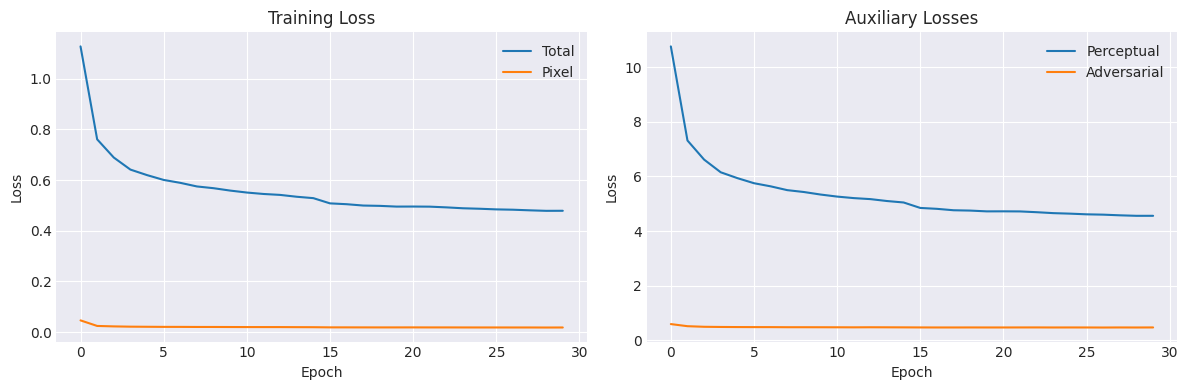

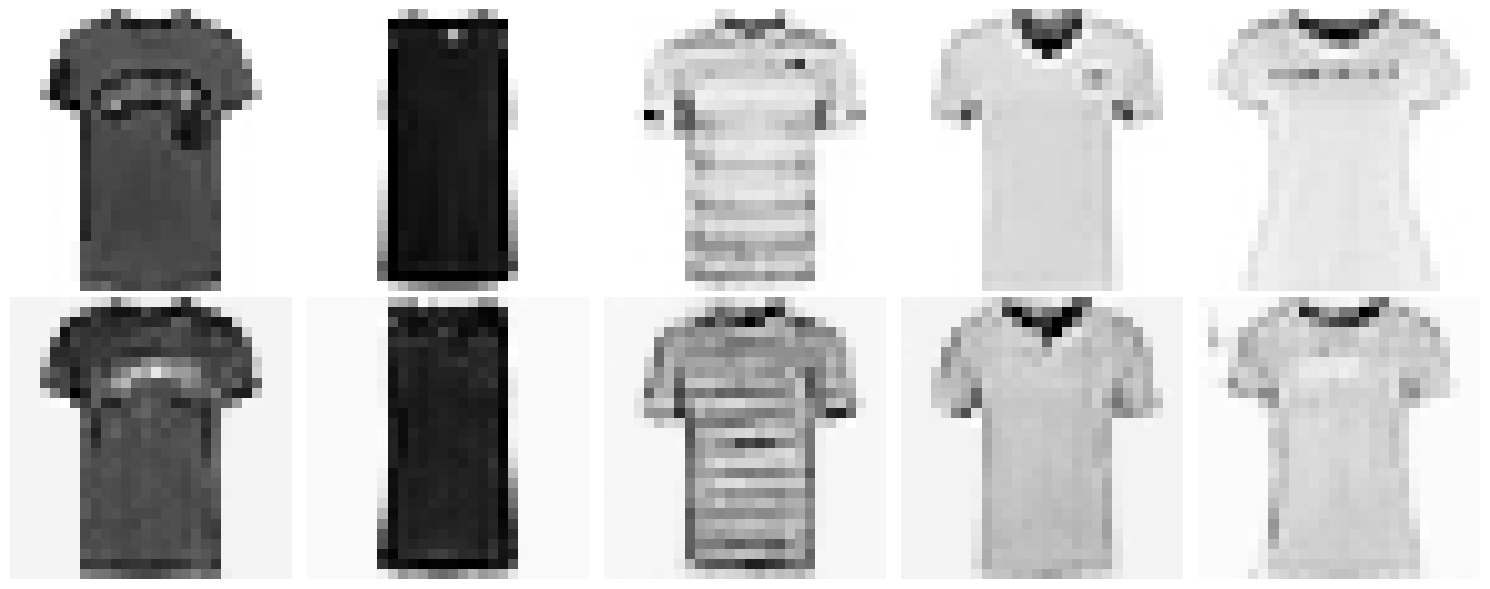

In [13]:
encoder, history = train_encoder(
     encoder, gen, discr, train_loader,
     n_epochs=N_EPOCHS, lr=LR,
     lambda_perceptual=LAMBDA_PERCEPTUAL, 
     lambda_adv=LAMBDA_ADV,
     save_dir='/teamspace/studios/this_studio/CF-Robustness-Benchmark/src/cf_methods/c3lt/weights/fmnist'
 )

# Check results
plot_training_history(history)
visualize_reconstructions(encoder, gen, test_loader)